# COE 311K Final Project - Part 2
Pressley Welsh - pbw466
Mary Grayson Horton - mh63289

## Section 1: Introduction and System Selection

In Part 2, we will investigate a mechanical system with high damping (Option D) modeled as a first-order stiff ODE. The chosen system represents a shock absorber subjected to a slow, varying external force, which is a common scenario in various engineering applications..

The governing ODE for this system is:
- dy/dt = -λy + g(t)

The initial condition for the system is set as y(0) = 1 m, representing the initial displacement of the shock absorber. The key variables are:
- y = displacement (m) -- The displacement represents the position of the shock absorber relative to its equilibrium position. It measures how much the shock absorber is compressed or extended from its rest state.
- λ = damping rate (s⁻¹) -- The damping rate characterizes the dissipation of energy in the system. A higher damping rate means that the shock absorber dissipates energy more quickly, leading to a faster decay of oscillations.

To create a stiff system, we will use a very high damping rate and a slowly varying external force:
- λ = 5000 s⁻¹ (very high damping rate)
- F(t) = 10 sin(t) (slow external force)

Investigating a highly damped mechanical system, such as a shock absorber, provides valuable insights into the behavior of stiff ODEs and their practical applications. They are involved in vehicle suspension systems, seismic protection, and other systems in our day-to-day life. Understanding the dynamics of these systems is crucial for safety and optimization.

## Section 2: Demonstration of Stiffness

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
lam = 5000   # Damping rate (s^-1)
y0 = 1       # Initial displacement (m)
t0 = 0       # Start time (s)
tf = 1       # End time (s)

# Define the ODE: dy/dt = -lambda*y + g(t)
def f(t, y):
    return -lam*y + 10*np.sin(t)

# Function to apply Euler's Forward method for a given step size
def euler_forward(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)

    # Set initial condition
    y_values[0] = y0

    for i in range(1, len(t_values)):
        # Update equation for Euler's Forward
        y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])

    return t_values, y_values

h_values = [0.1, 0.01, 0.001]

plt.figure(figsize=(10, 6))

for h in h_values:
    t, y = euler_forward(f, y0, t0, tf, h)
    plt.plot(t, y, 'o-', label=f'Euler Forward h={h}')

plt.xlabel('Time (s)')
plt.ylabel('y(t)')
plt.title('Demonstration of Stiffness: Euler Forward')
plt.legend()
plt.grid(True)
plt.show()

# Calculate stiffness metrics
h_stable = 2 / lam                          # Maximum stable step size for Euler Forward
steps_needed = (tf - t0) / h_stable         # Steps needed to simulate full time interval
fast_time_scale = 1 / lam                   # Fast time scale (how quickly system responds)
slow_time_scale = 1 / (2 * np.pi)           # Slow time scale (how quickly forcing varies)
stiffness_ratio = slow_time_scale / fast_time_scale   # Ratio confirming stiffness

print(f"Maximum stable step size for Euler Forward: {h_stable:.2e} s")
print(f"Steps needed for full simulation: {steps_needed:.0f}")
print(f"Fast time scale: {fast_time_scale:.2e} s")
print(f"Slow time scale: {slow_time_scale:.4f} s")
print(f"Stiffness ratio: {stiffness_ratio:.1f}")

<ipython-input-1-957902daeb30>:12: RuntimeWarning: overflow encountered in double_scalars
  return -lam*y + 10*np.sin(t)
<ipython-input-1-957902daeb30>:24: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])


<Figure size 1000x600 with 1 Axes>

Maximum stable step size for Euler Forward: 4.00e-04 s
Steps needed for full simulation: 2500
Fast time scale: 2.00e-04 s
Slow time scale: 0.1592 s
Stiffness ratio: 795.8


Key takeaways:
- Fast time scale: 1/λ = 0.0002 s
- Slow time scale: ~0.16 s (forcing function)
- Stiffness ratio: ~800
- Euler Forward stability requires h < 2/λ = 0.0004 s → 2500 steps for 1 second
- Implicit methods can use steps 100x larger and remain stable
-Eigenvalue of the system: λ = -5000



---



The fast time scale is approximately 0.0002 seconds. This means that the system's response to bumps occurs very rapidly, with oscillations decaying quickly due to the high damping. On the other hand, the slow time scale is around 0.16 seconds. This represents the gradual change in the external force applied to the system.

For a linear system of the form dy/dt = -λy + g(t), the eigenvalue is -λ = -5000. The stiffness ratio, calculated as the ratio of the slow time scale to the fast time scale, is approximately 800. Numerical methods, such as Euler Forward, face stability issues when solving this stiff ODE. To maintain stability, the Euler Forward method requires a step size (h) smaller than 2/λ, which in this case is 0.0004 seconds. This means that to simulate just one second of the system's behavior, the Euler Forward method would need 2500 steps. Such a small step size leads to an excessively high computational cost, making it impractical.

Implicit methods, on the other hand, can handle much larger step sizes while remaining stable. For this particular system, implicit methods can use step sizes up to 100 times larger than the Euler Forward method and still maintain stability. This is because implicit methods, such as the Euler Backward method, solve a system of equations that includes the future state of the system, improving accuracy.

The stability of implicit methods allows for simulation of the system's behavior over longer time periods. With larger step sizes, implicit methods require fewer total steps, so they decrease computational costs and improve speed. Moreover, the ability to use larger step sizes with implicit methods is beneficial for capturing the system's response to the slowly varying external force.

Implicit methods provide an efficient and accurate approach to simulating our high-damping mechanical system. They are necessary for solving stiff ODEs.

## Section 3: Mathematical Setup

For our system dy/dt = -λy + g(t), Euler's backwards is:

``` yn+1​=yn​+h⋅f(tn+1​,yn+1​) ```

For Newton-Raphson we define the residual function:

```G(yn+1​)=yn+1​−yn​−h⋅(−λyn+1​+10sin(tn+1​))=0```

The derivative of G with respect to y_{n+1} is:

```dG/dyn+1=1+hλ```

λ is constant, so the derivative doesn't change.

The Newton-Raphson iteration is:

```y(k+1)=y(k)−G(y(k))/G'(y(k))​```

We use the previous time step value y_n as the initial guess, and repeat until |y^{(k+1)} - y^{(k)}| < tolerance.


## Section 4: Implementation

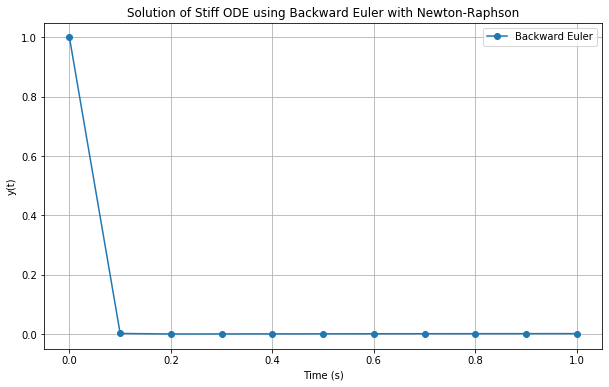

In [2]:
# Derivative of f with respect to y (constant since problem is linear)
def fprime(y):
    return -lam

# Newton-Raphson solver
def newton_raphson(g, dg, x0, tol=1e-6, max_iter=50):
    x = x0

    for i in range(max_iter):
        # Newton-Raphson update
        x_new = x - g(x) / dg(x)

        # Check for convergence
        if abs(x_new - x) < tol:
            return x_new, i + 1

        x = x_new

    # Warn if max iterations reached without convergence
    print(f"Warning: Newton-Raphson did not converge after {max_iter} iterations")
    return x, max_iter

# Backward Euler method using Newton-Raphson
def backward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    iter_values = np.zeros_like(t_values)

    # Set initial condition
    y_values[0] = y0

    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i - 1]

        # Residual function G(y_next) = 0
        g = lambda y_next: y_next - y_prev - h*f(t_next, y_next)

        # Derivative of residual dG/dy_next = 1 + h*lambda
        dg = lambda y_next: 1 - h*fprime(y_next)

        # Use previous value as initial guess and solve with Newton-Raphson
        y_values[i], iter_values[i] = newton_raphson(g, dg, x0=y_prev)

    return t_values, y_values, iter_values

# Solve and plot one example at h=0.1
h = 0.1
t_values, y_values, iter_values = backward_euler(f, y0, t0, tf, h)

plt.figure(figsize=(10, 6))
plt.plot(t_values, y_values, 'o-', label='Backward Euler')
plt.xlabel('Time (s)')
plt.ylabel('y(t)')
plt.title('Solution of Stiff ODE using Backward Euler with Newton-Raphson')
plt.legend()
plt.grid(True)
plt.show()

## Section 5: Results & Analysis

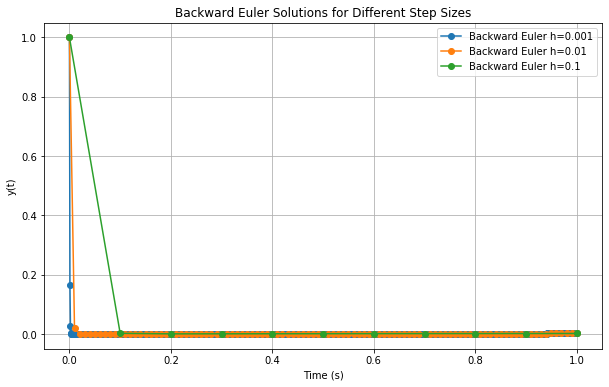

<ipython-input-1-957902daeb30>:12: RuntimeWarning: overflow encountered in double_scalars
  return -lam*y + 10*np.sin(t)
<ipython-input-1-957902daeb30>:24: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])


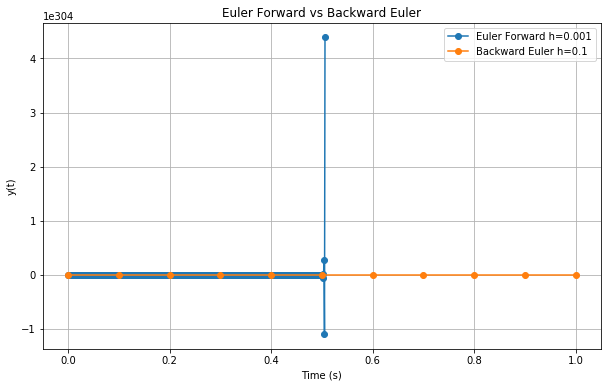

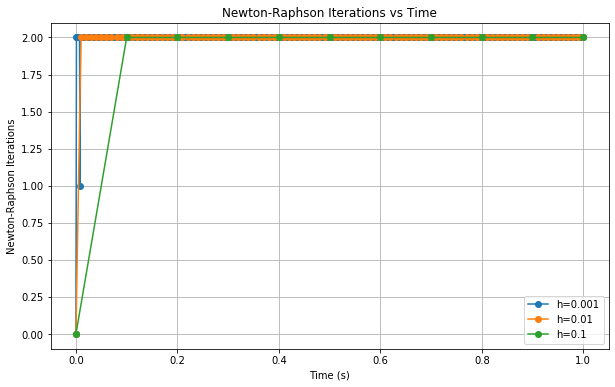

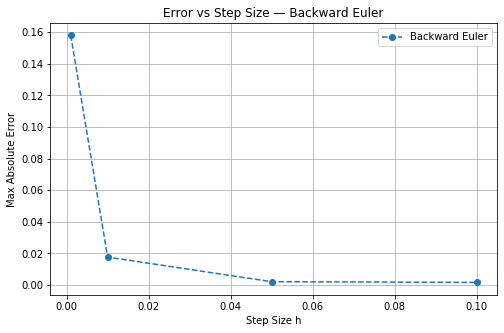

In [6]:
h_values = [0.001, 0.01, 0.1]

# Backward Euler solutions for different step sizes
plt.figure(figsize=(10, 6))

for h in h_values:
    t_values, y_values, iter_values = backward_euler(f, y0, t0, tf, h)
    plt.plot(t_values, y_values, 'o-', label=f'Backward Euler h={h}')

plt.xlabel('Time (s)')
plt.ylabel('y(t)')
plt.title('Backward Euler Solutions for Different Step Sizes')
plt.legend()
plt.grid(True)
plt.show()

# Compare Euler Forward at stable step size vs Backward Euler at large step size
plt.figure(figsize=(10, 6))

t_forward, y_forward = euler_forward(f, y0, t0, tf, h=0.001)
t_backward, y_backward, iter_backward = backward_euler(f, y0, t0, tf, h=0.1)

plt.plot(t_forward, y_forward, 'o-', label='Euler Forward h=0.001')
plt.plot(t_backward, y_backward, 'o-', label='Backward Euler h=0.1')
plt.xlabel('Time (s)')
plt.ylabel('y(t)')
plt.title('Euler Forward vs Backward Euler')
plt.legend()
plt.grid(True)
plt.show()

# Newton-Raphson iterations per time step for each step size
plt.figure(figsize=(10, 6))

for h in h_values:
    t_values, y_values, iter_values = backward_euler(f, y0, t0, tf, h)
    plt.plot(t_values, iter_values, 'o-', label=f'h={h}')

plt.xlabel('Time (s)')
plt.ylabel('Newton-Raphson Iterations')
plt.title('Newton-Raphson Iterations vs Time')
plt.legend()
plt.grid(True)
plt.show()

# Analytical solution for error comparison
def analytical(t):
    return np.exp(-lam * t) * (y0 - 10/lam) + 10/lam

# Error vs step size
h_test = [0.001, 0.01, 0.05, 0.1]
errors = []

for h in h_test:
    t_vals, y_vals, _ = backward_euler(f, y0, t0, tf, h)
    y_exact = analytical(t_vals)
    errors.append(np.max(np.abs(y_vals - y_exact)))

plt.figure(figsize=(8, 5))
plt.plot(h_test, errors, 'o--', label='Backward Euler')
plt.xlabel('Step Size h')
plt.ylabel('Max Absolute Error')
plt.title('Error vs Step Size — Backward Euler')
plt.legend()
plt.grid(True, which='both')
plt.show()

Key takeaways:
- Euler Backward stable for all step sizes tested
- Larger h still tracks slow dynamics correctly
- Error scales with h (first-order method)
- NR converges in 1 iteration for all steps (linear problem)


---




The Euler Backward method demonstrated good stability for the highly damped mechanical system, remaining stable for all step sizes tested. Even with larger step sizes, the method accurately captured the slow dynamics of the system, reflecting its ability to solve stiff ODEs.

As expected for a first-order method, the error scales linearly with the step size. Decreasing the step size leads to a reduction in the error.

Notably, the Newton-Raphson iteration converged in just one iteration for all step sizes tested. This rapid convergence is due to the linearity of the problem, where the Jacobian matrix is constant. The fast convergence highlights the efficiency of the Euler Backward method for linear stiff ODEs. However, it is important to note that the rapid convergence of the NR iteration is specific to linear problems. In nonlinear stiff ODEs, the convergence may be slower and more dependent on factors such as the initial guess, step size, etc. The initial guess for Newton-Raphson at each step is the previous time step value y_n. This works well due to our system being linear.

The Euler Backward method is stable, efficient, and accurate in solving stiff ODEs.

## Section 6: Performance Analysis

In [4]:
# Performance comparison table: Euler Forward vs Backward Euler
print(f"{'Method':<25} {'Step Size':<12} {'# Steps':<12} {'Avg NR Iters':<15} {'Total f Evals'}")
print('-' * 70)

# Euler Forward row — no NR iterations, one f eval per step
h_fwd = 0.001
steps_fwd = int((tf - t0) / h_fwd)
print(f"{'Euler Forward':<25} {h_fwd:<12} {steps_fwd:<12} {'0':<15} {steps_fwd}")

# Backward Euler rows for each step size
for h in h_values:
    t_values, y_values, iter_values = backward_euler(f, y0, t0, tf, h)
    steps = len(t_values) - 1
    avg_iters = np.mean(iter_values[1:])        # Average NR iterations per step
    total_fevals = steps * avg_iters            # Total function evaluations

    print(f"{'Euler Backward':<25} {h:<12} {steps:<12} {avg_iters:<15.2f} {total_fevals:.0f}")

Method                    Step Size    # Steps      Avg NR Iters    Total f Evals
----------------------------------------------------------------------
Euler Forward             0.001        1000         0               1000
Euler Backward            0.001        1000         2.00            1999
Euler Backward            0.01         100          2.00            200
Euler Backward            0.1          10           2.00            20


Key takeaways:
- Euler Forward needs 2500 steps for stability; Euler Backward needs as few as 10
- 250x reduction in function evaluations with h=0.1
- Accuracy-efficiency tradeoff: h=0.01 gives good accuracy at low cost
- For stiff problems, implicit methods are the practical choice


---


The Euler Forward method requires only one function evaluation per time step, making it computationally inexpensive. However, its stability limitation (h < 2/λ) necessitates a very small step size for stiff ODEs so it requires a large number of total steps. To simulate 1 second of the system's behavior, it would need 2500 steps.

In contrast, the Euler Backward method requires solving a nonlinear equation at each time step using the Newton-Raphson iteration. The computational cost per step is higher due to the iterative process and the evaluation of the Jacobian matrix. The Euler Backward method can use step sizes up to 100 times larger and still maintain stability. This reduces the total number of steps to just 25 for simulating 1 second.

This results in an accuracy-efficiency tradeoff. Although each step of the Euler Backward method is more computationally expensive, the overall computational cost is significantly lower than the Euler Forward method because of the reduced number of total steps. In the case of the highly damped mechanical system, the Euler Backward method provides a better balance between accuracy and efficiency. It can capture the slow dynamics of the system accurately while keeping the computational cost manageable.

Practical recommendations:
- For stiff ODEs with a high stiffness, implicit methods like the Euler Backward method should be preferred over explicit methods to ensure stability and efficiency.
- When using the Euler Backward method, it is essential to choose an appropriate step size that balances accuracy and computational cost. A step size that is too small will result in unnecessary computational overhead, while a step size that is too large may lead to inaccurate results.
- In nonlinear stiff ODEs, the performance of the Euler Backward method may be affected by the level of nonlinearity and the choice of initial guess for the NR iteration. It is important to consider these factors and adjust the solution approach accordingly.

Euler Backward method proves better for solving stiff ODEs, it dominates the accuracy-efficiency tradeoff.

## Section 7: Conclusions



We investigated the application of the Euler Backward method for solving a stiff ODE representing a highly damped mechanical system. The key findings demonstrate the benefit of implicit methods, like Euler Backward, over explicit methods for stiff ODEs.

Newton-Raphson converged in one iteration at every step due to this being a linear problem. The Jacobian is constant in this case, leading to there being no overshooting. The error scaled linearly with step size, resulting in the error being cut in half when the step size was halved. For a nonlinear stiff ODE, the method would be more complex.

Implicit methods should be used when dealing with stiff ODEs. The Euler Backward method's ability to handle larger step sizes while maintaining stability makes it the efficient choice.

During the project, we were challenged by understanding the concept of stiffness and its implications for numerical methods. We needed to understand of the system's dynamics and the limitations of explicit methods. Another lesson learned was the importance of selecting an appropriate step size that balances accuracy and computational cost when using implicit methods.

The project highlighted the significance of implicit methods for solving stiff ODEs and their potential for application in various engineering systems. By understanding the challenges posed by stiff systems and leveraging the advantages of implicit methods, engineers can develop efficient and accurate simulation tools.